# EDA: Dataset Exploration

Exploratory analysis for the GNN–BERT music context project. This notebook
runs on the synthetic dataset by default (for pipeline validation); swap
in `datasets.load_fma` / `load_magnatagatune` / `load_musiccaps` / `load_deam`
once real data is downloaded under `data/raw/` (see Table 1 in the spec).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from datasets import make_synthetic_dataset, TOP_50_MAGNATAGATUNE_TAGS, GTZAN_GENRES

ds = make_synthetic_dataset(n_samples=300, num_tags=20, num_genres=8, seed=0)
print(f"{len(ds)} samples")

300 samples


## Genre / class balance

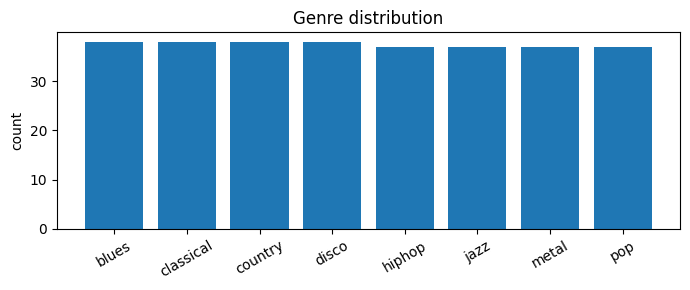

In [2]:
genre_counts = Counter(s.genre for s in ds)
labels = [GTZAN_GENRES[i] for i in sorted(genre_counts)]
counts = [genre_counts[i] for i in sorted(genre_counts)]

plt.figure(figsize=(7, 3))
plt.bar(labels, counts)
plt.title("Genre distribution"); plt.ylabel("count"); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## Tag frequency (top-K tags)

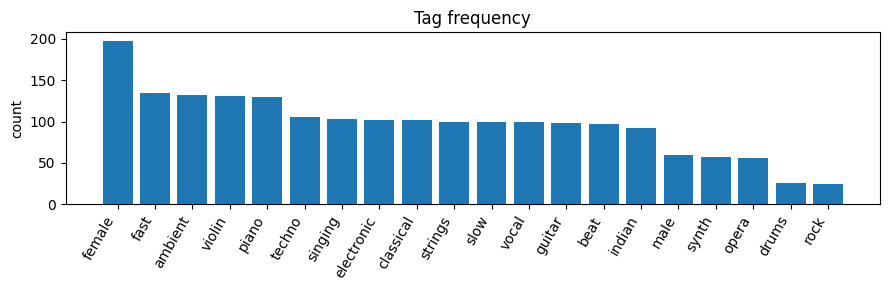

In [3]:
tag_freq = np.stack([s.tags for s in ds]).sum(axis=0)
order = np.argsort(-tag_freq)
tag_names = [TOP_50_MAGNATAGATUNE_TAGS[i] for i in order[:20]]

plt.figure(figsize=(9, 3))
plt.bar(tag_names, tag_freq[order[:20]])
plt.xticks(rotation=60, ha="right"); plt.title("Tag frequency"); plt.ylabel("count")
plt.tight_layout(); plt.show()

## Graph size distribution (nodes / edges per track)

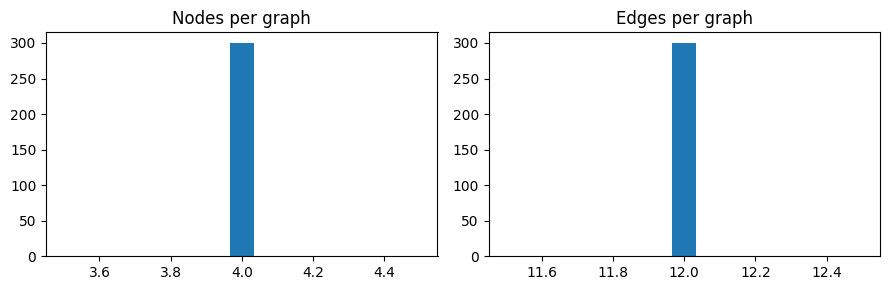

mean nodes: 4.0, mean edges: 12.0


In [4]:
n_nodes = [s.graph.num_nodes for s in ds]
n_edges = [len(s.graph.edge_index) for s in ds]

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(n_nodes, bins=15); axes[0].set_title("Nodes per graph")
axes[1].hist(n_edges, bins=15); axes[1].set_title("Edges per graph")
plt.tight_layout(); plt.show()

print(f"mean nodes: {np.mean(n_nodes):.1f}, mean edges: {np.mean(n_edges):.1f}")

## Valence / arousal distribution by genre

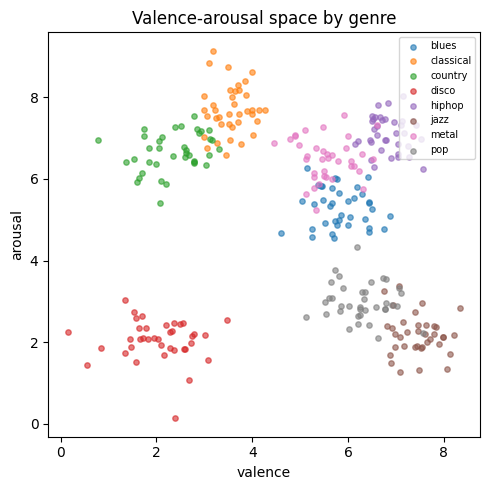

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
for g_idx in range(8):
    v = [s.valence for s in ds if s.genre == g_idx]
    a = [s.arousal for s in ds if s.genre == g_idx]
    ax.scatter(v, a, label=GTZAN_GENRES[g_idx], alpha=0.6, s=15)
ax.set_xlabel("valence"); ax.set_ylabel("arousal")
ax.set_title("Valence-arousal space by genre")
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()